# Alignment of HAADF images with SOFIMA

In [7]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Load haadf stack

In [8]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
EXD_summed_unaligned, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame=False)

print(haadf_stack.shape)
print(haadf_stack.max(),haadf_stack.dtype)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


(100, 2048, 2048)
65535.0 float64


#### Align based on the first 20 HAADf images 

In [3]:
sof_obj = get_alignment(haadf_stack, 
                  n_align = 20,
                  min_peak_ratio=1.1, 
                  min_peak_sharpness=1.1,
                  max_magnitude=0, 
                  max_deviation=0,
                  patch_size = 100,
                  stride = 25,
                  pad_remove = 50)

print(sof_obj.inv_map.shape)

  0%|          | 0/19 [00:00<?, ?it/s]

W0000 00:00:1765280833.175891 16085299 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765280833.213484 16085299 service.cc:145] XLA service 0x60000359b000 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765280833.213644 16085299 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765280833.214996 16085299 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765280833.215004 16085299 mps_client.cc:384] XLA backend will use up to 77309018112 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Max


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

(2, 20, 82, 82)


#### Apply the alignment 

In [4]:
haadf_stack_aligned = apply_alignment_2D(haadf_stack, sof_obj, 'uint8')

  0%|          | 0/19 [00:00<?, ?it/s]

#### Evaluate alignment performance (PCC between frames, before and after: can add other metrics later)

In [ ]:
print(haadf_stack.shape, haadf_stack_aligned.shape)
print(haadf_stack.dtype, haadf_stack_aligned.dtype)

In [5]:
# make sure the stacks have matched dimensions
pad_remove = sof_obj.pad_remove
haadf_stack = np.transpose(haadf_stack,[1,2,0])[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove, :20].astype('uint8')

print(haadf_stack.shape, haadf_stack_aligned.shape)
print(haadf_stack.dtype, haadf_stack_aligned.dtype)

(1948, 1948, 20) (1948, 1948, 20)
uint8 uint8


In [6]:
pcc_before, pcc_after = eval_alignment(haadf_stack, haadf_stack_aligned)
print('Pearson coeffients before and after: ', np.mean(pcc_before), np.mean(pcc_after))

Pearson coeffients before and after:  0.76144951622399 0.9373076849022679


#### Visualize the alignmed images

In [ ]:
# output folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outdir = f"results/alignments/{timestamp}"
os.makedirs(outdir, exist_ok=True)


for i in range(haadf_stack.shape[2]):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Right (aligned)
    ax[1].imshow(haadf_stack_aligned[:, :, i], cmap="gray_r")
    ax[1].set_title(f"Chan {i:d} corr with channel 0: {pcc_after[i]:.3f}")
    ax[1].axis("off")

    # Left (unaligned)
    ax[0].imshow(haadf_stack[:, :, i], cmap="gray_r")
    ax[0].set_title(f"Chan {i:d} corr with channel 0: {pcc_before[i]:.3f}")
    ax[0].axis("off")


    # Save figure
    outfile = os.path.join(outdir, f"slice_{i:03d}.png")
    plt.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Saved alignment figures to: {outdir}")


#### Save the alignment transformation

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/sofima_transforms/{timestamp}_sof_object.pkl", "wb") as f:
    pickle.dump(sof_obj, f)


#### Load the alignment 

In [3]:
import dill as pickle
with open(f"results/sofima_transforms/20251201_104453_sof_object.pkl", "rb") as f:
    sof_obj = pickle.load(f)


### Apply to the EDX cube

#### 1) TensorStore the unaligned EDX frames (this takes long)

In [ ]:
tmp = store_unaligned_hsi(file_path,'tmp/unaligned_hsi',n_frames=20)

### Create two EDX objects, one aligned, one not

#### load data from EMD

In [9]:
edx_unaligned, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame= False)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


#### Unaligned

In [13]:
tile_1 = EM_EDX(haadf[0,:,:], edx_unaligned, xray_energies)
tile_1.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_1.apply("binning", parameters={"dim": (2048, 2048, 250)})
#tile_1.apply("MeanFilterEDX", parameters={"kernel_size": 3})

<EM_EDX | 2 steps logged>

#### Aligned

In [34]:
pad_remove = sof_obj.pad_remove
tile_2 = EM_EDX(haadf[0,:,:], edx_unaligned, xray_energies)
tile_2.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_2.apply("binning", parameters={"dim": (2048, 2048, 250)})


<EM_EDX | 2 steps logged>

In [43]:
# Align
tile_2.apply("sofima_align", parameters={"hsi_stack_path": "tmp/unaligned_hsi", "alignment": sof_obj, "data_type": "float32",
                                        "save_aligned": True, "hsi_stack_aligned_path": "tmp/aligned_hsi"})   


  0%|          | 0/19 [00:00<?, ?it/s]

Channel 001 out of 250 has been aligned


  0%|          | 0/19 [00:00<?, ?it/s]

Channel 002 out of 250 has been aligned


  0%|          | 0/19 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

Channel 249 out of 250 has been aligned


  0%|          | 0/19 [00:00<?, ?it/s]

Channel 250 out of 250 has been aligned
Saved aligned HSI stack to: tmp/aligned_hsi


<EM_EDX | 3 steps logged>

#### Save an aligned tile to memory

In [ ]:
# save to memory
import pickle
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/preprocessed_edx/{timestamp}_tile_aligned.pkl", "wb") as f:
    pickle.dump(tile_2, f)



#### load the above

In [11]:
with open('results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile_2 = pickle.load(file)

tile_2.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None


#### Aligned cont.

In [ ]:
tile_2.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_2.summary()

#### Add meal filter

In [14]:
tile_3 = tile_1.apply("MeanFilterEDX", parameters={"kernel_size": 3},copy_instance='True')
tile_4 = tile_2.apply("MeanFilterEDX", parameters={"kernel_size": 3},copy_instance='True')

tiles = [tile_1,tile_2,tile_3,tile_4]
for tile in tiles:
    print(tile.summary())

  operation                                         parameters    haadf size  \
0      crop  crop_idx=(slice(None, None, None), slice(None,...  (2048, 2048)   
1   binning                              dim=(2048, 2048, 250)  (2048, 2048)   

             EDX size notes  
0  (2048, 2048, 4000)  None  
1   (2048, 2048, 250)  None  
      operation                                         parameters  \
0          crop  crop_idx=(slice(None, None, None), slice(None,...   
1       binning                              dim=(2048, 2048, 250)   
2  sofima_align  hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...   

     haadf size            EDX size notes  
0  (2048, 2048)  (2048, 2048, 4000)  None  
1  (2048, 2048)   (2048, 2048, 250)  None  
2  (2048, 2048)   (2048, 2048, 250)  None  
       operation                                         parameters  \
0           crop  crop_idx=(slice(None, None, None), slice(None,...   
1        binning                              dim=(2048, 2048, 250)   

Text(0.5, 1.0, 'aligned+MF')

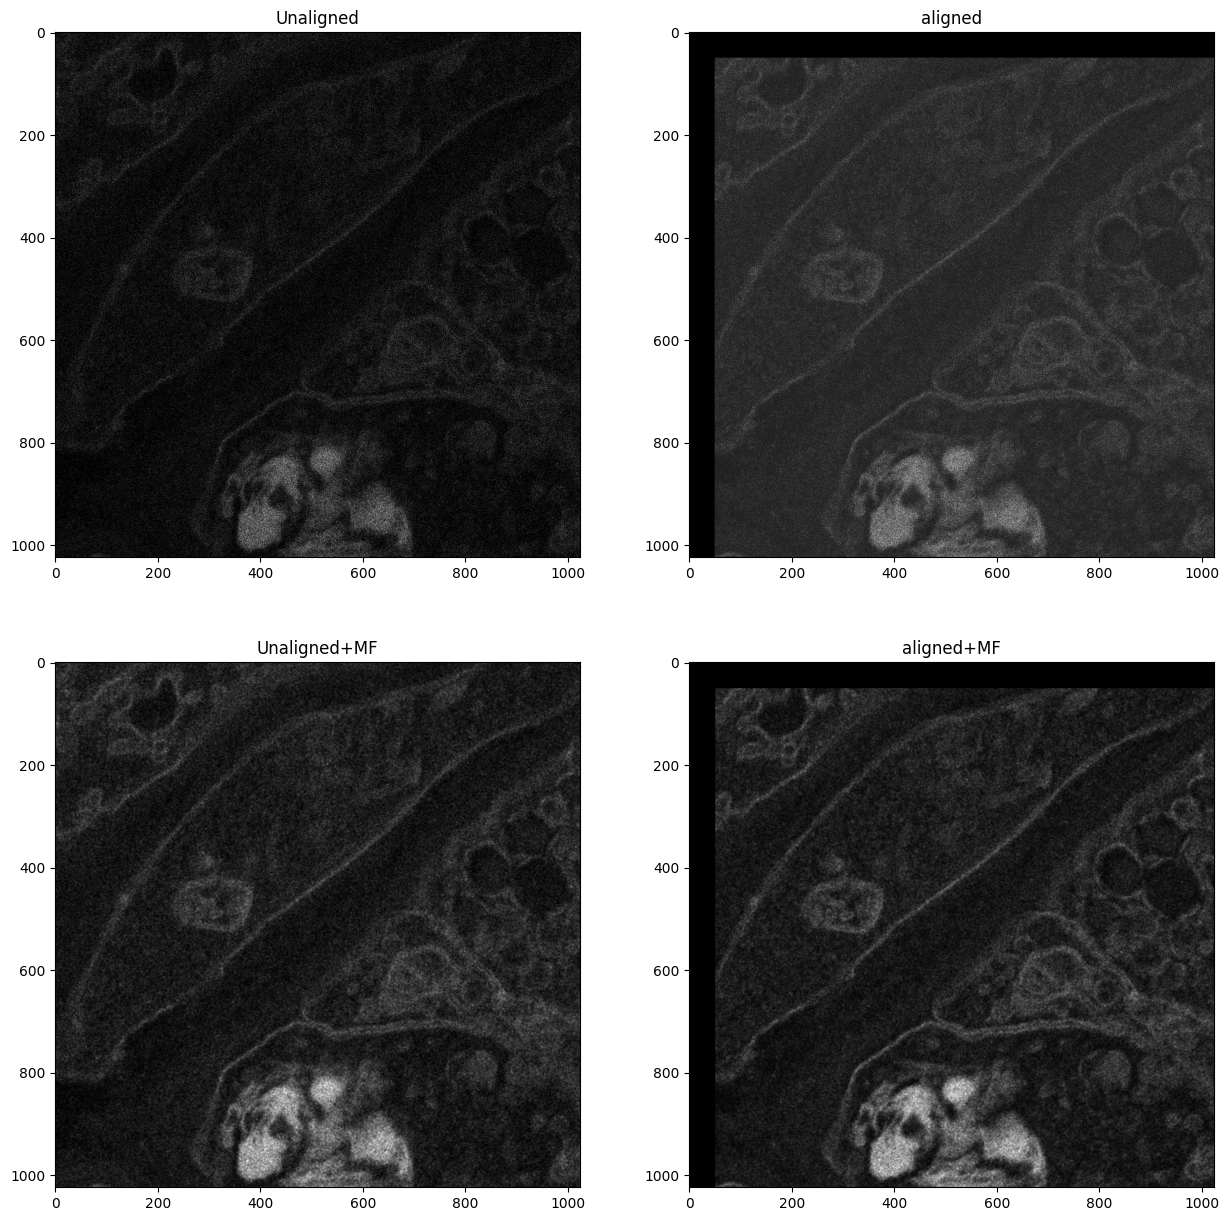

In [18]:
bands = [24,24,24]
f, ax = plt.subplots(2,2,figsize=(15,15))
#x1,x2,y1,y2 = [750,1000,250,750]
#x1,x2,y1,y2 = [600,1000,400,800]
x1,x2,y1,y2 = [0,1024,0,1024]


#ax[0][0].imshow(tile_1.FalseColor(bands)[x1:x2,y1:y2,:])
ax[0][0].imshow(tile_1.FalseColor(bands)[x1:x2,y1:y2,:])
ax[0][1].imshow(tile_2.FalseColor(bands)[x1:x2,y1:y2,:])


#tmp1 = tile_1.FalseColor(bands)[x1:x2,y1:y2,:]
#tmp2 = tile_2.FalseColor(bands)[x1:x2,y1:y2,:]
#print(np.array_equal(tmp1,tmp2))

ax[1][0].imshow(tile_3.FalseColor(bands)[x1:x2,y1:y2,:])
ax[1][1].imshow(tile_4.FalseColor(bands)[x1:x2,y1:y2,:])

ax[0][0].set_title('Unaligned')
ax[0][1].set_title('aligned')
ax[1][0].set_title('Unaligned+MF')
ax[1][1].set_title('aligned+MF')


## Sillhouette score

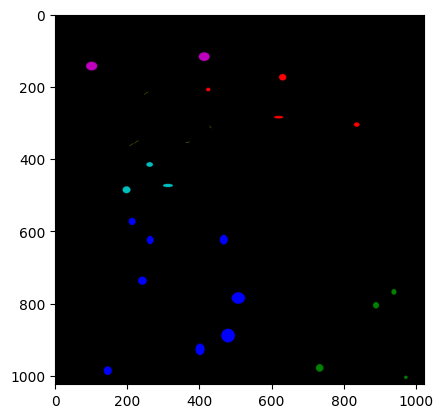

In [20]:
from sklearn.metrics import silhouette_samples
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# get the hand-annotated masks and display them
mask_dir = os.path.join(os.path.dirname(os.getcwd()),'data', 'masks_frame0_sil_specific')
masks = create_masks(mask_dir)
colors = ['k','r','g','b','c','m','y']
newcmap = ListedColormap(colors)
plt.imshow(masks,cmap=newcmap)
plt.show()

In [21]:
# taking care of NaN values that remain after binning - what a pain in the back
nanmask = np.isnan(x).all(axis=2)
pad_bin = 0
for r in range(nanmask.shape[0]):
    if nanmask[r, :].all():
        pad_bin += 1
    else:
        break

# compute sil scores for both
sil_img1 = sil_scores(tile_1.EDX[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin,:],
                      masks[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin], metric='euclidean')
sil_img2 = sil_scores(tile_2.EDX[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin,:],
                      masks[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin], metric='euclidean')
sil_img3 = sil_scores(tile_3.EDX[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin,:],
                      masks[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin], metric='euclidean')
sil_img4 = sil_scores(tile_4.EDX[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin,:],
                      masks[pad_bin:1024-pad_bin,pad_bin:1024-pad_bin], metric='euclidean')

# compute global vmin/vmax 
vmin = np.nanmin(np.array([sil_img1,sil_img2,sil_img3,sil_img4]))
vmax = np.nanmax(np.array([sil_img1,sil_img2,sil_img3,sil_img4]))

NameError: name 'x' is not defined

In [ ]:
# modify jet so NaNs appear black
cmap = plt.cm.jet.copy()
cmap.set_bad(color='black')

bands=[4,25,28]
f, ax = plt.subplots(4,2,figsize=(10, 25))
ax[0][0].imshow(tile_1.FalseColor(bands))
ax[0][0].set_title('Unaligned')
ax[1][0].imshow(tile_2.FalseColor(bands))
ax[1][0].set_title('Aligned')
ax[2][0].imshow(tile_3.FalseColor(bands))
ax[2][0].set_title('Unaligned mean filter')
ax[3][0].imshow(tile_4.FalseColor(bands))
ax[3][0].set_title('Aligned mean filter')

im = ax[0][1].imshow(sil_img1,cmap=cmap,vmin=vmin,vmax=vmax)
ax[0][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img1),fontsize=10)
im = ax[1][1].imshow(sil_img2,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img2),fontsize=10)
im = ax[2][1].imshow(sil_img3,cmap=cmap,vmin=vmin,vmax=vmax)
ax[2][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img3),fontsize=10)
im = ax[3][1].imshow(sil_img4,cmap=cmap,vmin=vmin,vmax=vmax)
ax[3][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img4),fontsize=10)

for i in range(4):
    for j in range(2):
        ax[i][j].axis('off')

# one shared colorbar
plt.colorbar(im, ax=ax.ravel().tolist(), shrink=0.2,location='top')

#plt.tight_layout()
plt.show()

### Exporting HAADF for additional annotation

In [ ]:
import tifffile as tf
tf.imwrite('/Users/aj/Desktop/haadf_00.tiff', Normalize_uint8(1-binning_xy(haadf_stack[0,:,:])))
tf.imwrite('/Users/aj/Desktop/haadf_19.tiff', Normalize_uint8(1-binning_xy(haadf_stack[19,:,:])))
tf.imwrite('/Users/aj/Desktop/haadf_99.tiff', Normalize_uint8(1-binning_xy(haadf_stack[99,:,:])))